# RandomWalkChangepointMeanVar1D Model Demo

This notebook demonstrates the `RandomWalkChangepointMeanVar1D` model with synthetic data, including model fitting, comparison of fit outputs to the generating parameters, and ELBO-based selection of the number of states.

Unlike pytau's other changepoint models (which assume each observation is drawn i.i.d. from a state-dependent emission distribution), this model treats the observed 1D data as a **random walk** (`x_t = x_{t-1} + innovation_t`) and detects changepoints in the **mean and variance of the innovation (step) distribution**.

In [1]:
import numpy as np
# Try to import matplotlib, create dummy if not available
try:
    import matplotlib.pyplot as plt
except ImportError:
    print('matplotlib not available - creating dummy plt object')
    class DummyPlt:
        def __getattr__(self, name):
            def dummy_func(*args, **kwargs):
                pass
            return dummy_func
    plt = DummyPlt()
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add pytau to path
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), '..', '..'))

from pytau.changepoint_model import (
    RandomWalkChangepointMeanVar1D,
    random_walk_changepoint_mean_var_1d,
    advi_fit,
    find_best_states,
)
import arviz as az

## Generate Test Data

Generated random walk of length: 150
Data range: [-19.73, 20.70]
State (innovation) means: [0.5, -0.8, 0.2]
State (innovation) stds: [0.4, 1.2, 0.7]
Transition points (step index): [50, 100]


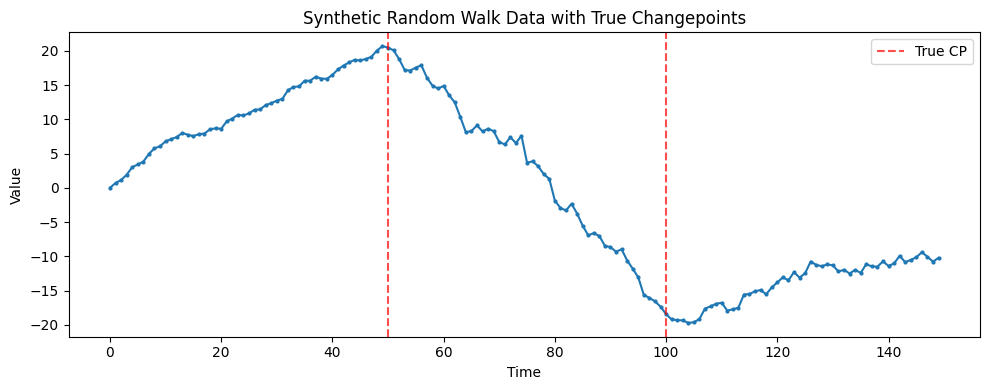

In [2]:
# Generate a synthetic 1D random walk with known changepoints in the
# mean (drift) and variance (volatility) of the innovation distribution
np.random.seed(42)
n_time = 150
n_states = 3

# Innovation (step) mean and std per state
state_means = [0.5, -0.8, 0.2]
state_stds = [0.4, 1.2, 0.7]
transition_points = [50, 100]  # changepoints in the innovation (step) series

n_steps = n_time - 1
bounds = [0] + transition_points + [n_steps]

innovations = np.zeros(n_steps)
for i in range(n_states):
    start, end = bounds[i], bounds[i + 1]
    innovations[start:end] = np.random.normal(state_means[i], state_stds[i], end - start)

test_data = np.concatenate([[0.0], np.cumsum(innovations)])

print(f"Generated random walk of length: {test_data.shape[0]}")
print(f"Data range: [{test_data.min():.2f}, {test_data.max():.2f}]")
print(f"State (innovation) means: {state_means}")
print(f"State (innovation) stds: {state_stds}")
print(f"Transition points (step index): {transition_points}")

plt.figure(figsize=(10, 4))
plt.plot(test_data, '-o', markersize=2)
for tp in transition_points:
    plt.axvline(x=tp, color='red', linestyle='--', alpha=0.7, label='True CP' if tp == transition_points[0] else None)
plt.title('Synthetic Random Walk Data with True Changepoints')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

## Initialize and Generate Model

In [3]:
# Initialize model
model = RandomWalkChangepointMeanVar1D(
    data_array=test_data,
    n_states=n_states,
)

# Generate the PyMC model
pymc_model = model.generate_model()
print("Model generated successfully")
print(f"Model variables: {list(pymc_model.named_vars.keys())}")

Model generated successfully
Model variables: ['mu', 'sigma', 'a_tau', 'b_tau', 'tau_latent', 'tau', 'obs']


## Fit Model with ADVI

In [4]:
# Fit the model using ADVI
print("Fitting model with ADVI...")
n_fit = 6000  # Number of ADVI iterations
n_samples = 500  # Number of samples to draw

result = advi_fit(pymc_model, n_fit, n_samples)
if len(result) == 6:
    fitted_model, approx, mu_stack, sigma_stack, tau_samples, observed_data = result
else:
    fitted_model, approx, mu_stack, tau_samples, observed_data = result
    sigma_stack = None

# Sample from the fitted model
trace = approx.sample(draws=n_samples)

print(f"Model fitting completed. Final ELBO: {approx.hist[-1]:.2f}")
print(f"Trace variables: {list(trace.posterior.data_vars)}")

Fitting model with ADVI...
Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 Average Loss = 230.19
Model fitting completed. Final ELBO: 205.95
Trace variables: ['a_tau', 'b_tau', 'mu', 'sigma', 'tau', 'tau_latent']


## Extract and Analyze Fitted Parameters

In [5]:
# Extract fitted parameters
mu_samples = trace.posterior['mu'].values     # Innovation means per state
sigma_samples = trace.posterior['sigma'].values  # Innovation stds per state
tau_samples = trace.posterior['tau'].values      # Changepoint locations (step index)

print(f"Mu (innovation means) shape: {mu_samples.shape}")
print(f"Sigma (innovation stds) shape: {sigma_samples.shape}")
print(f"Tau (changepoints) shape: {tau_samples.shape}")

# Average over chains and draws
mu_mean = mu_samples.mean(axis=(0, 1))
sigma_mean = sigma_samples.mean(axis=(0, 1))
tau_mean = tau_samples.mean(axis=(0, 1))

print("\nEstimated innovation means (state):")
for state in range(n_states):
    print(f"  State {state + 1}: {mu_mean[state]:.3f} (true: {state_means[state]:.3f})")

print("\nEstimated innovation stds (state):")
for state in range(n_states):
    print(f"  State {state + 1}: {sigma_mean[state]:.3f} (true: {state_stds[state]:.3f})")

print("\nEstimated changepoints (step index):")
for i in range(len(transition_points)):
    print(f"  CP {i + 1}: {tau_mean[i]:.1f} (true: {transition_points[i]})")

print(f"\nELBO convergence (last 10 values): {[f'{x:.2f}' for x in approx.hist[-10:]]}")

Mu (innovation means) shape: (1, 500, 3)
Sigma (innovation stds) shape: (1, 500, 3)
Tau (changepoints) shape: (1, 500, 2)

Estimated innovation means (state):
  State 1: 0.318 (true: 0.500)
  State 2: -0.602 (true: -0.800)
  State 3: 0.052 (true: 0.200)

Estimated innovation stds (state):
  State 1: 0.988 (true: 0.400)
  State 2: 1.429 (true: 1.200)
  State 3: 1.211 (true: 0.700)

Estimated changepoints (step index):
  CP 1: 52.2 (true: 50)
  CP 2: 96.5 (true: 100)

ELBO convergence (last 10 values): ['238.53', '227.08', '196.92', '220.60', '214.10', '222.94', '231.25', '216.44', '222.86', '205.95']


## Visualize Original Data vs Model Fit

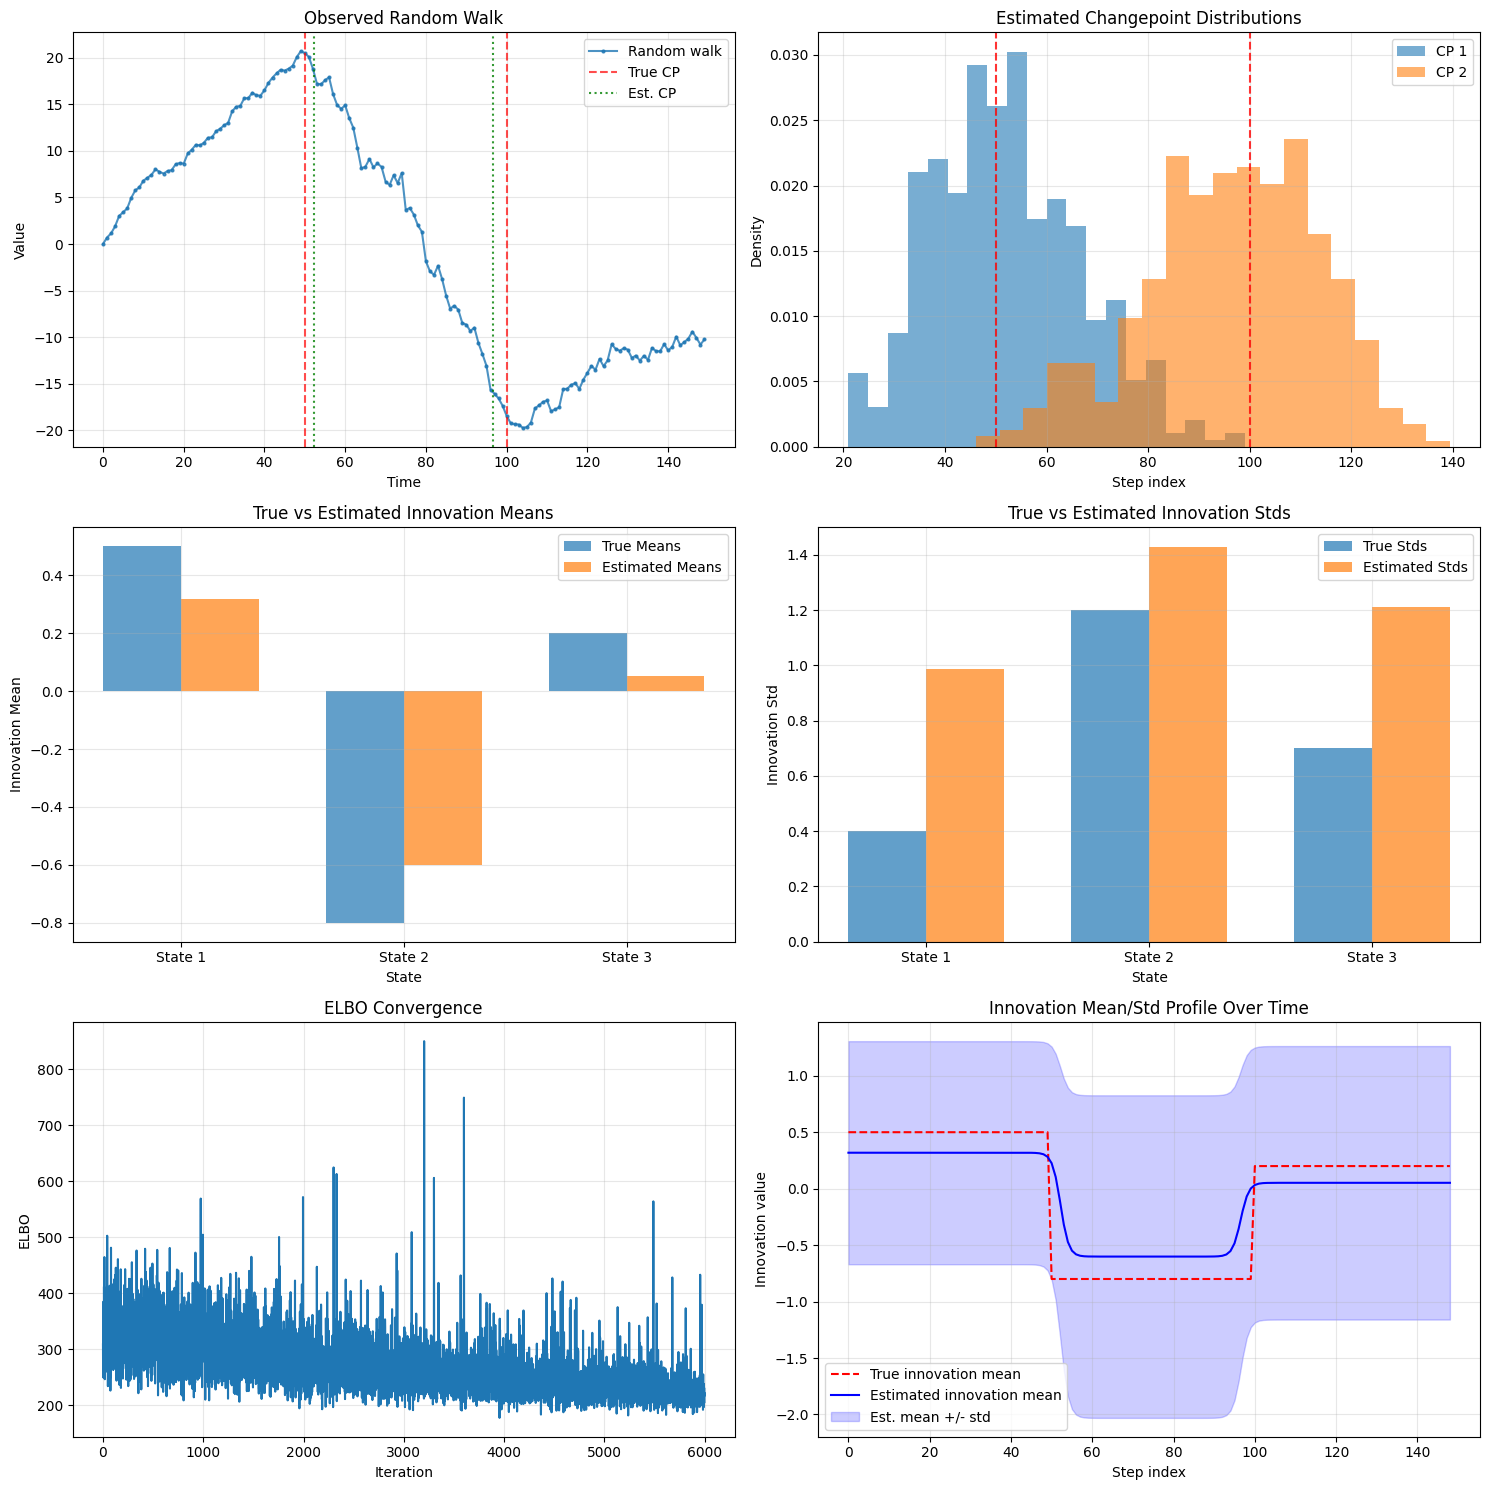

In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def compute_weight_stack(idx, tau, n_states):
    length = len(idx)
    weight_stack = sigmoid(idx[np.newaxis, :] - tau[:, np.newaxis])
    weight_stack = np.concatenate([np.ones((1, length)), weight_stack], axis=0)
    inverse_stack = 1 - weight_stack[1:]
    inverse_stack = np.concatenate([inverse_stack, np.ones((1, length))], axis=0)
    return weight_stack * inverse_stack


# Reconstruct the fitted time-varying innovation mean/std profile
idx = np.arange(n_steps)
weight_stack = compute_weight_stack(idx, tau_mean, n_states)
mu_t_est = mu_mean.dot(weight_stack)
sigma_t_est = sigma_mean.dot(weight_stack)

# True innovation mean/std profile
true_mu_t = np.zeros(n_steps)
true_sigma_t = np.zeros(n_steps)
for i in range(n_states):
    start, end = bounds[i], bounds[i + 1]
    true_mu_t[start:end] = state_means[i]
    true_sigma_t[start:end] = state_stds[i]

fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# 1. Original data with true and estimated changepoints
ax = axes[0, 0]
ax.plot(test_data, 'o-', markersize=2, alpha=0.8, label='Random walk')
for i, tp in enumerate(transition_points):
    ax.axvline(x=tp, color='red', linestyle='--', alpha=0.7, label='True CP' if i == 0 else None)
for i, tp in enumerate(tau_mean):
    ax.axvline(x=tp, color='green', linestyle=':', alpha=0.8, label='Est. CP' if i == 0 else None)
ax.set_title('Observed Random Walk')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Estimated changepoint distributions
ax = axes[0, 1]
for i in range(tau_samples.shape[-1]):
    cp_data = tau_samples[..., i].flatten()
    ax.hist(cp_data, bins=20, alpha=0.6, label=f'CP {i + 1}', density=True)
    ax.axvline(x=transition_points[i], color='red', linestyle='--', alpha=0.8)
ax.set_title('Estimated Changepoint Distributions')
ax.set_xlabel('Step index')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. True vs estimated innovation means
ax = axes[1, 0]
x_pos = np.arange(n_states)
width = 0.35
ax.bar(x_pos - width / 2, state_means, width, label='True Means', alpha=0.7)
ax.bar(x_pos + width / 2, mu_mean, width, label='Estimated Means', alpha=0.7)
ax.set_title('True vs Estimated Innovation Means')
ax.set_xlabel('State')
ax.set_ylabel('Innovation Mean')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'State {i + 1}' for i in range(n_states)])
ax.legend()
ax.grid(True, alpha=0.3)

# 4. True vs estimated innovation stds
ax = axes[1, 1]
ax.bar(x_pos - width / 2, state_stds, width, label='True Stds', alpha=0.7)
ax.bar(x_pos + width / 2, sigma_mean, width, label='Estimated Stds', alpha=0.7)
ax.set_title('True vs Estimated Innovation Stds')
ax.set_xlabel('State')
ax.set_ylabel('Innovation Std')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'State {i + 1}' for i in range(n_states)])
ax.legend()
ax.grid(True, alpha=0.3)

# 5. ELBO convergence
ax = axes[2, 0]
ax.plot(approx.hist)
ax.set_title('ELBO Convergence')
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.grid(True, alpha=0.3)

# 6. True vs fitted innovation mean/std profile over time
ax = axes[2, 1]
ax.plot(true_mu_t, 'r--', label='True innovation mean')
ax.plot(mu_t_est, 'b-', label='Estimated innovation mean')
ax.fill_between(idx, mu_t_est - sigma_t_est, mu_t_est + sigma_t_est, alpha=0.2, color='blue', label='Est. mean +/- std')
ax.set_title('Innovation Mean/Std Profile Over Time')
ax.set_xlabel('Step index')
ax.set_ylabel('Innovation value')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Diagnostics

In [7]:
print("=== MODEL DIAGNOSTICS ===")
print(f"\nData shape: {test_data.shape}")
print(f"Number of states: {n_states}")
print(f"ADVI iterations: {n_fit}")
print(f"Final ELBO: {approx.hist[-1]:.2f}")

print(f"\n=== PARAMETER ESTIMATES ===")
print("Innovation Means (mu):")
for i in range(n_states):
    est_mean = mu_mean[i]
    est_std = mu_samples[..., i].std()
    print(f"  State {i + 1}: {est_mean:.3f} +/- {est_std:.3f} (true: {state_means[i]:.3f})")

print("\nInnovation Stds (sigma):")
for i in range(n_states):
    est_std_mean = sigma_mean[i]
    est_std_std = sigma_samples[..., i].std()
    print(f"  State {i + 1}: {est_std_mean:.3f} +/- {est_std_std:.3f} (true: {state_stds[i]:.3f})")

print("\nChangepoints (tau):")
for i in range(len(transition_points)):
    est_cp = tau_mean[i]
    est_std = tau_samples[..., i].std()
    print(f"  CP {i + 1}: {est_cp:.1f} +/- {est_std:.1f} (true: {transition_points[i]})")

elbo_diff = np.diff(approx.hist[-100:])
print(f"\n=== CONVERGENCE ===")
print(f"Mean ELBO change (last 100 iter): {elbo_diff.mean():.4f}")
print(f"Std ELBO change (last 100 iter): {elbo_diff.std():.4f}")

=== MODEL DIAGNOSTICS ===

Data shape: (150,)
Number of states: 3
ADVI iterations: 6000
Final ELBO: 205.95

=== PARAMETER ESTIMATES ===
Innovation Means (mu):
  State 1: 0.318 +/- 0.342 (true: 0.500)
  State 2: -0.602 +/- 0.379 (true: -0.800)
  State 3: 0.052 +/- 0.346 (true: 0.200)

Innovation Stds (sigma):
  State 1: 0.988 +/- 0.410 (true: 0.400)
  State 2: 1.429 +/- 0.522 (true: 1.200)
  State 3: 1.211 +/- 0.431 (true: 0.700)

Changepoints (tau):
  CP 1: 52.2 +/- 14.5 (true: 50)
  CP 2: 96.5 +/- 17.0 (true: 100)

=== CONVERGENCE ===
Mean ELBO change (last 100 iter): -0.1432
Std ELBO change (last 100 iter): 44.5780


## Model Selection: Using ELBO to Identify the Number of States

`find_best_states` fits the model across a range of candidate state counts and picks the one with the lowest final ELBO. ADVI/ELBO comparisons are inherently noisy, so this is typically accurate to within +/-1 state rather than exact on every run.

Fitting model with 2 states
Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 Average Loss = 271.59
Fitting model with 3 states
Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 Average Loss = 274.31
Fitting model with 4 states
Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 Average Loss = 277.36
Fitting model with 5 states
Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 Average Loss = 280.65
ELBO by state count: {2: 249.76, 3: 210.37, 4: 290.54, 5: 226.4}
Selected number of states (lowest ELBO): 3 (true: 3)


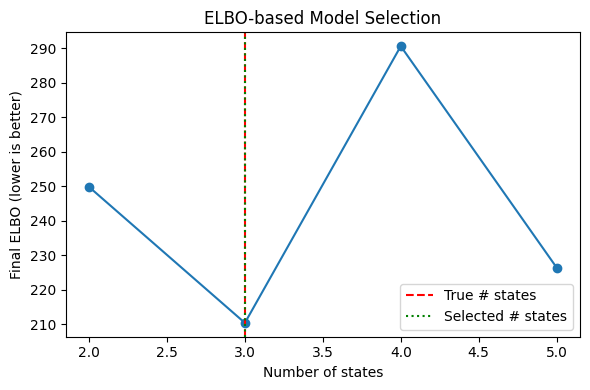

In [8]:
min_states, max_states = 2, 5
best_model, model_list, elbo_values = find_best_states(
    test_data,
    random_walk_changepoint_mean_var_1d,
    n_fit=3000,
    n_samples=200,
    min_states=min_states,
    max_states=max_states,
)

state_range = np.arange(min_states, max_states + 1)
best_n_states = state_range[np.argmin(elbo_values)]

print(f"ELBO by state count: {dict(zip(state_range, np.round(elbo_values, 2)))}")
print(f"Selected number of states (lowest ELBO): {best_n_states} (true: {n_states})")

plt.figure(figsize=(6, 4))
plt.plot(state_range, elbo_values, 'o-')
plt.axvline(x=n_states, color='red', linestyle='--', label='True # states')
plt.axvline(x=best_n_states, color='green', linestyle=':', label='Selected # states')
plt.xlabel('Number of states')
plt.ylabel('Final ELBO (lower is better)')
plt.title('ELBO-based Model Selection')
plt.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:
1. **Data Generation**: Creating a synthetic 1D random walk with known changepoints in both the mean (drift) and variance (volatility) of the innovation distribution.
2. **Model Initialization**: Setting up `RandomWalkChangepointMeanVar1D`, which models the observed data as a `pm.GaussianRandomWalk` with time-varying innovation parameters.
3. **Model Fitting**: Using ADVI to fit the model to data.
4. **Parameter Extraction**: Extracting and comparing fitted innovation means, stds, and changepoint locations against the true generating parameters.
5. **Model Selection**: Using ELBO comparisons (`find_best_states`) to identify the number of states directly from the data.